In [1]:
import os
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from random import shuffle
%matplotlib inline

In [6]:
data_path = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\data"

In [7]:
def label_image(img):
  pet = img.split('.')[-3]
  if pet == 'cat': return 0
  elif pet == 'dog': return 1

In [8]:
input_dir = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\data\train"
output_dir = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\datafolder"

In [9]:
image_list = os.listdir(input_dir)
shuffle(image_list)

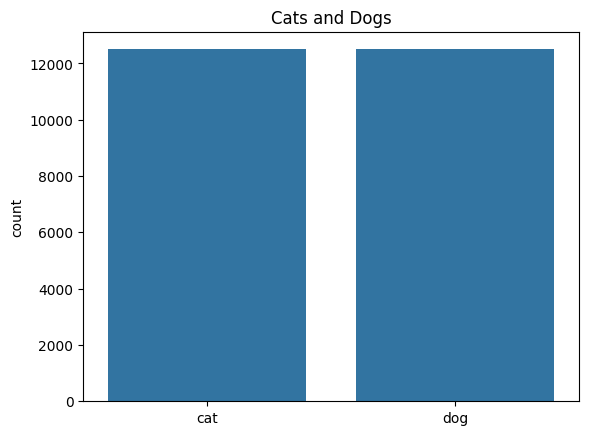

In [10]:
def plot_image_folder_count(image_folder):
  labels = []
  for img in image_folder:
    labels.append(img.split('.')[-3])
  sns.countplot(x=labels, orient='v')
  plt.title('Cats and Dogs')

plot_image_folder_count(image_list)

In [ ]:
# import os
# import shutil

# def merge_folders(source_folders, destination_folder):
#     """
#     Merges the contents of multiple source folders into a single destination folder.

#     Args:
#         source_folders: A list of paths to the source folders.
#         destination_folder: The path to the destination folder.
#     """
#     if not os.path.exists(destination_folder):
#         os.makedirs(destination_folder)

#     for folder in source_folders:
#         if os.path.exists(folder):
#             for filename in os.listdir(folder):
#                 source_path = os.path.join(folder, filename)
#                 destination_path = os.path.join(destination_folder, filename)

#                 if os.path.isfile(source_path):  # Check if it's a file
#                     shutil.copy2(source_path, destination_path) # copy2 preserves metadata
#                 else:
#                     print(f"Skipping non-file item: {source_path}")  # Handle directories or other non-files
#         else:
#             print(f"Warning: Source folder not found: {folder}")


# # Example usage:
# cat_folder = '/content/data/Cat'  # Replace with the actual paths
# dog_folder = '/content/data/Dog'
# merged_folder = '/content/merged_data'

# merge_folders([cat_folder, dog_folder], merged_folder)


In [ ]:
def process_data(image_list, output):
  for img_filename in tqdm(image_list):
    img_path = os.path.join(input_dir, img_filename)
    label = label_image(img_filename)
    img = Image.open(img_path)

    if label == 0:
      output_dir = os.path.join(output, 'cat')
    elif label == 1:
      output_dir = os.path.join(output, 'dog')

    if not os.path.exists(output_dir):
      os.makedirs(output_dir)

    img.save(os.path.join(output_dir, img_filename))

process_data(image_list, './datafolder')

In [13]:
train_data = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\datafolder"

In [14]:
train_data, test_data = train_test_split(image_list, test_size=0.2, random_state=42)

In [15]:
test_data, val_data = train_test_split(test_data, test_size=0.5, random_state=42)

In [16]:
process_data(train_data, './data_split/train')
process_data(test_data, './data_split/test')
process_data(val_data, './data_split/val')

100%|██████████| 2500/2500 [00:16<00:00, 151.73it/s]


In [14]:
# process_data(train_data, './data_folder/train')
# process_data(test_data, './data_folder/test')
# process_data(val_data, './data_folder/val')

In [17]:
train_cat_dir = './data_split/train/cat'
train_dog_dir = './data_split/train/dog'

test_cat_dir = './data_split/test/cat'
test_dog_dir = './data_split/test/dog'

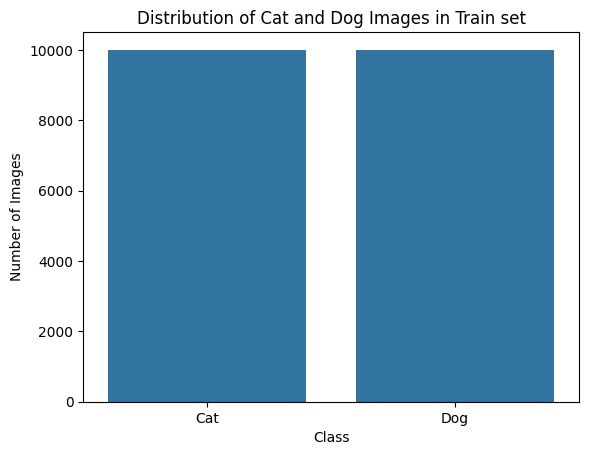

In [18]:
def visualize_distribution(cat_dir, dog_dir):
  num_train_cat = len(os.listdir(cat_dir))
  num_train_dog = len(os.listdir(dog_dir))

  sns.barplot(x=['Cat', 'Dog'], y=[num_train_cat, num_train_dog])
  plt.title('Distribution of Cat and Dog Images in Train set')
  plt.xlabel('Class')
  plt.ylabel('Number of Images')
  plt.show()

visualize_distribution(train_cat_dir, train_dog_dir)

In [19]:
nrows = 4
ncols = 4

In [24]:
train_dir = os.path.join(r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\data_split", "train")
train_cats_dir = os.path.join(train_dir, 'cat')
train_dogs_dir = os.path.join(train_dir, 'dog')

In [26]:
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)
pic_index = 100
train_cat_fnames = os.listdir(train_cats_dir)
train_dog_fnames = os.listdir(train_dogs_dir)

<Figure size 1600x1600 with 0 Axes>

In [27]:
next_cat_pix = [os.path.join(train_cats_dir, fname)
                for fname in train_cat_fnames[pic_index - 8:pic_index]
               ]

next_dog_pix = [os.path.join(train_dogs_dir, fname)
                for fname in train_dog_fnames[pic_index - 8:pic_index]
               ]

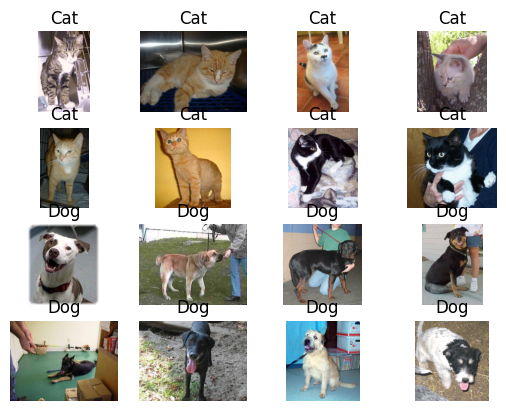

In [28]:
for i, img_path in enumerate(next_cat_pix + next_dog_pix):
    sp = plt.subplot(nrows, ncols, i + 1)
    sp.axis('Off')

    img = mpimg.imread(img_path)
    label = "Cat" if "cat" in img_path else "Dog"
    plt.imshow(img)
    plt.title(label, fontsize=12)

plt.show()

In [29]:
import imghdr
from PIL import Image
import os
import pandas as pd
import matplotlib.pyplot as plt

C:\Users\Admin\AppData\Local\Temp\ipykernel_18512\759158264.py:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [31]:
cat_folder_path = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\data_split\train\cat"
dog_folder_path = r"C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\CatDog\data_split\train\dog"

In [32]:
def get_image_info(folder_path):
  pic_info = {}
  for file_name in os.listdir(folder_path):
    path = os.path.join(folder_path, file_name)
    if os.path.isfile(path) and imghdr.what(path) is not None:
      if file_name not in pic_info:
        img = Image.open(path)
        pic_info[file_name] = img.size
  return pic_info

In [33]:
def visualize_distribution(folder_path, label):
  pic_info = get_image_info(folder_path)
  widths = [shape[0] for shape in pic_info.values()]
  heights = [shape[1] for shape in pic_info.values()]

  df = pd.DataFrame({'width': widths, 'height': heights})
  print(f"Summary statistics for {label} images:")
  print(df.describe())

  df.hist(column=['width', 'height'], bins=30, color='blue', alpha=0.7, figsize=(10, 5))
  plt.suptitle(f'Distribution of {label} Images')
  plt.show()

Summary statistics for Cat images:
             width       height
count  9990.000000  9990.000000
mean    410.460360   356.234334
std     108.035057    96.746015
min      50.000000    32.000000
25%     335.000000   299.000000
50%     470.000000   374.000000
75%     499.000000   406.750000
max    1023.000000   768.000000


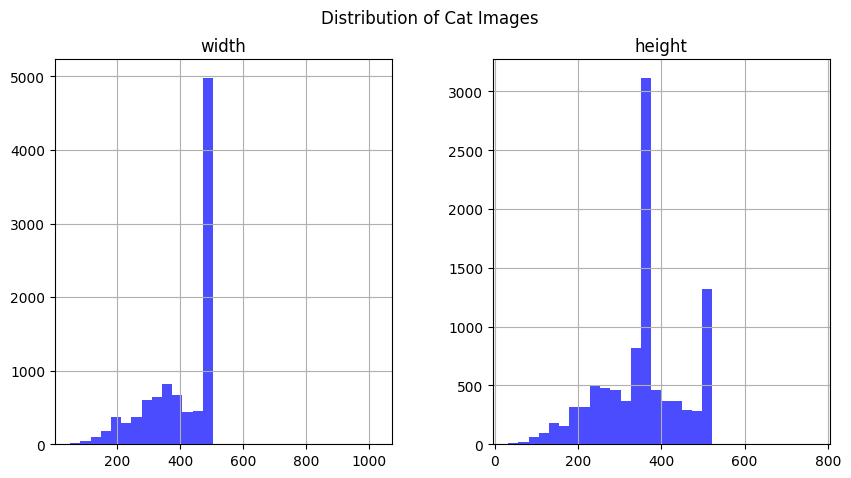

In [34]:
visualize_distribution(cat_folder_path, 'Cat')

Summary statistics for Dog images:
              width        height
count  10010.000000  10010.000000
mean     397.060140    363.880919
std      109.882694     96.948636
min       50.000000     37.000000
25%      319.000000    305.000000
50%      421.000000    374.000000
75%      499.000000    432.000000
max     1050.000000    702.000000


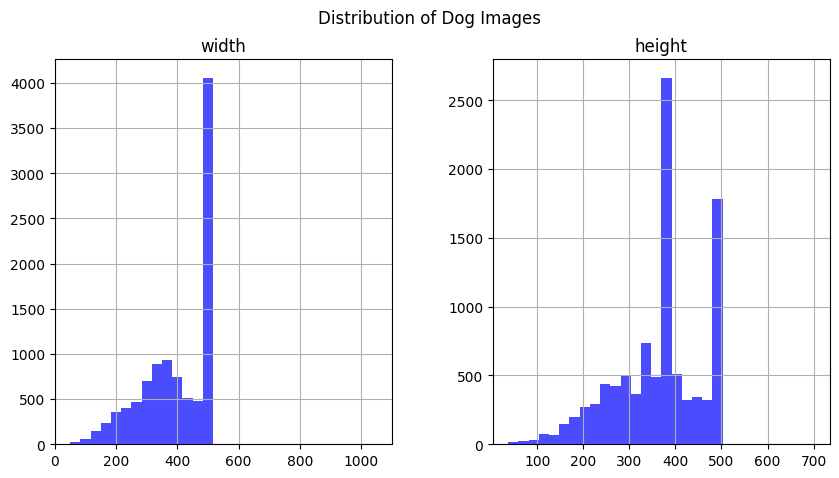

In [35]:
visualize_distribution(dog_folder_path, 'Dog')

In [36]:
def visualize_smallest_largest(folder_path, label):
  pic_info = get_image_info(folder_path)

  smallest_width_img = min(pic_info, key=lambda x: pic_info[x][0])
  largest_width_img = max(pic_info, key=lambda x: pic_info[x][0])

  fig, axs = plt.subplots(1, 2, figsize=(10, 6))

  smallest_img = mpimg.imread(os.path.join(folder_path, smallest_width_img))
  axs[0].imshow(smallest_img)
  axs[0].set_title(f"Smallest Width | {smallest_width_img}")

  largest_img = mpimg.imread(os.path.join(folder_path, largest_width_img))
  axs[1].imshow(largest_img)
  axs[1].set_title(f"Largest Width | {largest_width_img}")

  plt.suptitle(f'{label} Image: Smallest and Largest Width')
  plt.show()

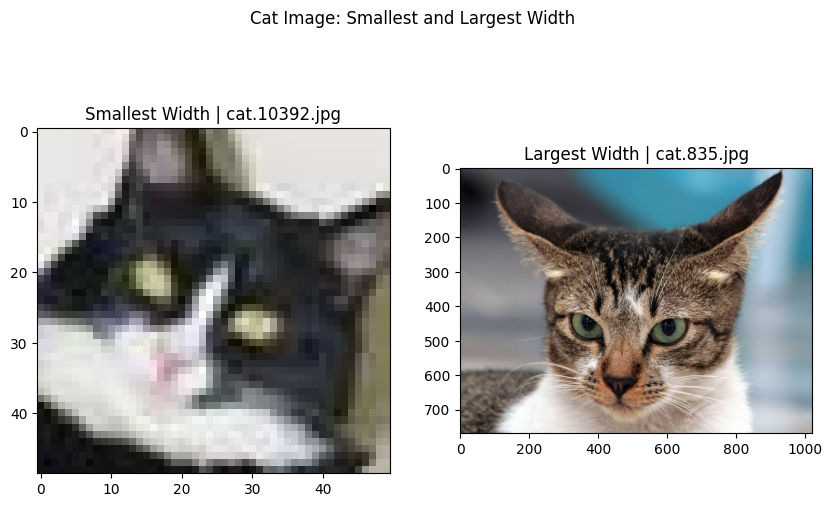

In [37]:
visualize_smallest_largest(cat_folder_path, 'Cat')

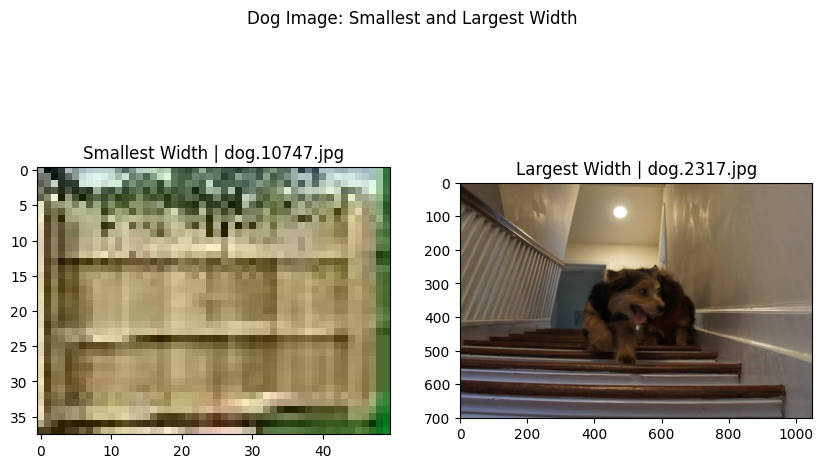

In [38]:
visualize_smallest_largest(dog_folder_path, 'Dog')